# EDA

### Imports + Config

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import os

# Load config
with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

# Plot styling
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:.2f}".format)

print("Libraries loaded.")

Libraries loaded.


### Load data

In [5]:
import os
os.chdir("..")  # move from notebooks/ up to repo root

filepath = config["data"]["raw_dir"] + config["data"]["lending_club_file"]
df = pd.read_csv(filepath, low_memory=False)
print(f"Rows: {len(df):,}  |  Columns: {df.shape[1]}")
df.head()

Rows: 2,260,701  |  Columns: 151


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.00,3600.00,3600.00,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.00,24700.00,24700.00,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.00,20000.00,20000.00,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.00,35000.00,35000.00,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.00,10400.00,10400.00,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


### Create binary target variable

In [7]:
# Keep only loans with a clear outcome
df = df[df["loan_status"].isin(["Fully Paid", "Charged Off"])]

# Binary target: 1 = default, 0 = repaid
df["default"] = (df["loan_status"] == "Charged Off").astype(int)

print(f"Rows after filtering: {len(df):,}")
print(f"\nDefault rate: {df['default'].mean():.1%}")

Rows after filtering: 1,345,310

Default rate: 20.0%


C:\Users\micro\AppData\Local\Temp\ipykernel_28724\285483588.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["default"] = (df["loan_status"] == "Charged Off").astype(int)


### Class imbalance

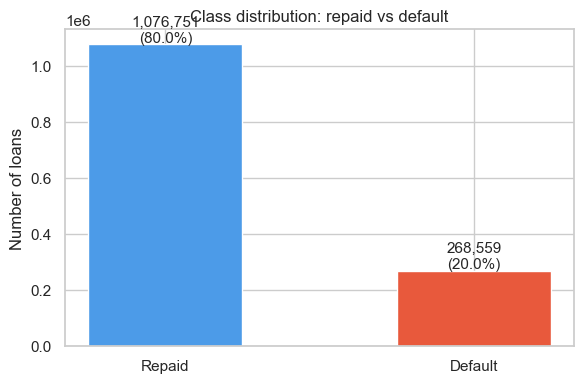

In [ ]:
counts = df["default"].value_counts()
labels = ["Repaid", "Default"]
colors = ["#4C9BE8", "#E8593C"]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(labels, counts.values, color=colors, width=0.5)
ax.set_title("Class distribution: repaid vs default")
ax.set_ylabel("Number of loans")
for i, v in enumerate(counts.values):
    ax.text(i, v + 10000, f"{v:,}\n({v/len(df):.1%})", ha="center", fontsize=11)
plt.tight_layout()
plt.show()

### Default rate by loan grade

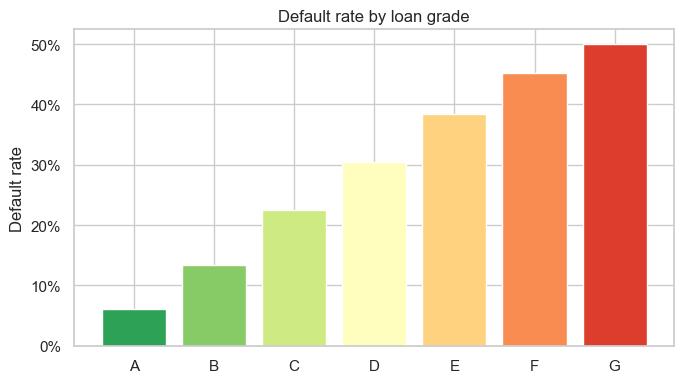

,grade,default_rate
0,A,0.06
1,B,0.13
2,C,0.22
3,D,0.30
4,E,0.38
5,F,0.45
6,G,0.50


In [9]:
grade_default = df.groupby("grade")["default"].mean().reset_index()
grade_default.columns = ["grade", "default_rate"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(grade_default["grade"], grade_default["default_rate"],
              color=sns.color_palette("RdYlGn_r", len(grade_default)))
ax.set_title("Default rate by loan grade")
ax.set_ylabel("Default rate")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
plt.tight_layout()
plt.show()

grade_default

### DTI and income by default status

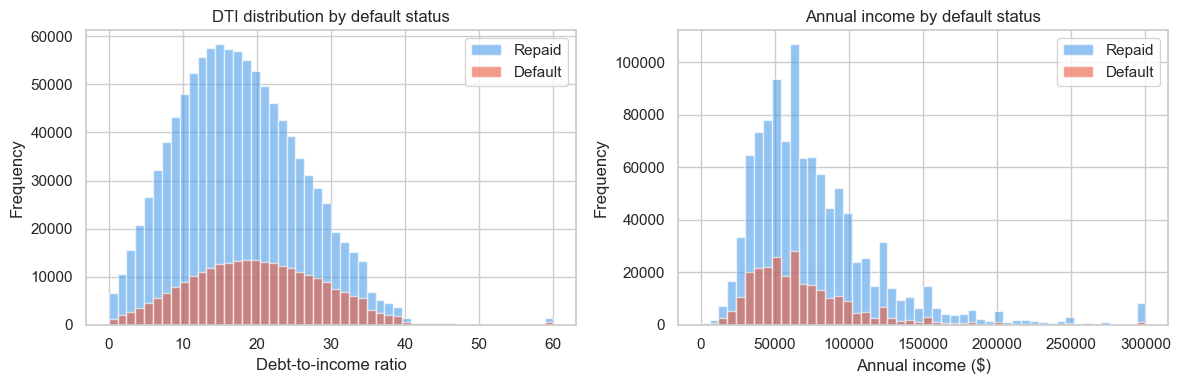

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# DTI distribution
df[df["default"]==0]["dti"].clip(0, 60).plot.hist(
    ax=axes[0], bins=50, alpha=0.6, color="#4C9BE8", label="Repaid")
df[df["default"]==1]["dti"].clip(0, 60).plot.hist(
    ax=axes[0], bins=50, alpha=0.6, color="#E8593C", label="Default")
axes[0].set_title("DTI distribution by default status")
axes[0].set_xlabel("Debt-to-income ratio")
axes[0].legend()

# Annual income distribution (log scale)
df[df["default"]==0]["annual_inc"].clip(0, 300000).plot.hist(
    ax=axes[1], bins=50, alpha=0.6, color="#4C9BE8", label="Repaid")
df[df["default"]==1]["annual_inc"].clip(0, 300000).plot.hist(
    ax=axes[1], bins=50, alpha=0.6, color="#E8593C", label="Default")
axes[1].set_title("Annual income by default status")
axes[1].set_xlabel("Annual income ($)")
axes[1].legend()

plt.tight_layout()
plt.show()

### Key Stats:

In [11]:
summary = df.groupby("default")[["loan_amnt", "int_rate", "dti", "annual_inc"]].mean()
summary.index = ["Repaid", "Default"]
summary.columns = ["Avg loan amount", "Avg interest rate", "Avg DTI", "Avg annual income"]
summary.round(2)

,Avg loan amount,Avg interest rate,Avg DTI,Avg annual income
Repaid,14134.37,12.62,17.81,77705.95
Default,15565.06,15.71,20.17,70400.74
